In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from matplotlib.ticker import AutoMinorLocator
import scipy.optimize as sc

base_path = Path.cwd()

data_path = base_path / 'Data' / 'Datasheet.xlsx'
img_path = base_path.parent.parent / '31' / 'Images'

Data50Tab = pd.read_excel(data_path, sheet_name='T = 50°C',engine='openpyxl')
Data48Tab = pd.read_excel(data_path, sheet_name='T = 48°C',engine='openpyxl')
Data45Tab = pd.read_excel(data_path, sheet_name='T = 45 °C',engine='openpyxl')
Data42Tab = pd.read_excel(data_path, sheet_name='T = 42°C',engine='openpyxl')
Data40Tab = pd.read_excel(data_path, sheet_name='T = 40°C',engine='openpyxl')
Data35Tab = pd.read_excel(data_path, sheet_name='T = 35°C',engine='openpyxl')
Data30Tab = pd.read_excel(data_path, sheet_name='T = 30 °C',engine='openpyxl')

Data30 = np.array([[x,y] for x,y in zip(Data30Tab['Druck [10^5 Pa]'].tolist(), Data30Tab['Volumen [ml]'].tolist())])
Data35 = np.array([[x,y] for x,y in zip(Data35Tab['Druck [10^5 Pa]'].tolist(), Data35Tab['Volumen [ml]'].tolist())])
Data40 = np.array([[x,y] for x,y in zip(Data40Tab['Druck [10^5 Pa]'].tolist(), Data40Tab['Volumen [ml]'].tolist())])
Data42 = np.array([[x,y] for x,y in zip(Data42Tab['Druck [10^5 Pa]'].tolist(), Data42Tab['Volumen [ml]'].tolist())])
Data45 = np.array([[x,y] for x,y in zip(Data45Tab['Druck [10^5 Pa]'].tolist(), Data45Tab['Volumen [ml]'].tolist())])
Data48 = np.array([[x,y] for x,y in zip(Data48Tab['Druck [10^5 Pa]'].tolist(), Data48Tab['Volumen [ml]'].tolist())])
Data50 = np.array([[x,y] for x,y in zip(Data50Tab['Druck [10^5 Pa]'].tolist(), Data50Tab['Volumen [ml]'].tolist())])

MGS = np.array([[24.0, 0.25], [27.5, 0.25], [30.5, 0.250], [32.25, 0.25], [34.5, 0.25], [37.5, 0.30]])
MGE = np.array([[24.0, 0.75], [27.25, 0.75], [30.5, 0.6], [32, 0.55], [34.5, 0.45], [37.5, 0.35]])


In [23]:
def pVPlot(T, Data, vdw=True, hert=0, ylim=30, xlim=4):
    plt.errorbar(Data[:,1], Data[:,0], fmt='x', label=f'T = {T} °C', xerr=0.025, yerr=0.03, color='black')
    if vdw:
        plt.hlines(y=hert, color='red', linestyle='--', xmin=-1, xmax=5, linewidth=0.8, label='Maxwell')
    plt.xlabel('Volumen [ml]')
    plt.ylabel('Druck [10$^5$ Pa]')
    plt.title(f'p V Relation bei {T}°C', loc='left')
    plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
    plt.xticks(np.arange(0, xlim+1, 0.5))
    plt.yticks(np.arange(0, ylim+1, 5))
    plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
    plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)
    plt.xlim(0, xlim)
    plt.ylim(0, ylim)
    plt.legend()
    plt.savefig(img_path / 'pV' /f'pV_T{T}.png', bbox_inches='tight')

## Plots

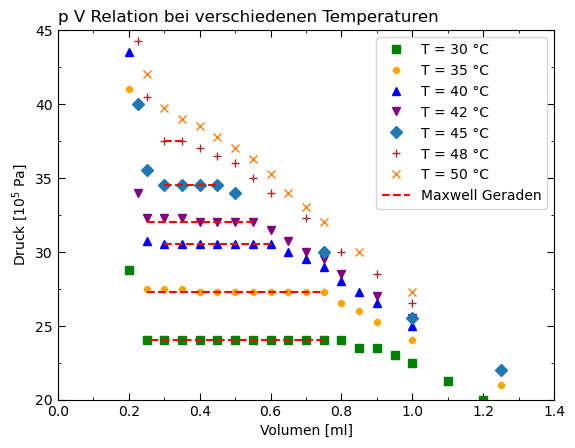

In [22]:
plt.plot(Data30[:,1], Data30[:,0], 's', label='T = 30 °C', color='green')
plt.hlines(y=24, color='red', linestyle='--', xmin=0.75, xmax=0.25, linewidth=1.5)
plt.plot(Data35[:,1], Data35[:,0], '8', label='T = 35 °C', color='orange', markersize=4)
plt.hlines(y=27.25, color='red', linestyle='--', xmin=0.25, xmax=0.75, linewidth=1.5)
plt.plot(Data40[:,1], Data40[:,0], '^', label='T = 40 °C', color='blue')
plt.hlines(y=30.5, color='red', linestyle='--', xmin=0.3, xmax=0.6, linewidth=1.5)
plt.plot(Data42[:,1], Data42[:,0], 'v', label='T = 42 °C', color='purple')
plt.hlines(y=32, color='red', linestyle='--', xmin=0.25, xmax=0.55, linewidth=1.5)
plt.plot(Data45[:,1], Data45[:,0], 'D', label='T = 45 °C')
plt.hlines(y=34.5, color='red', linestyle='--', xmin=0.3, xmax=0.45, linewidth=1.5)
plt.plot(Data48[:,1], Data48[:,0], '+', label='T = 48 °C', color='brown')
plt.plot(Data50[:,1], Data50[:,0], 'x', label='T = 50 °C')
plt.hlines(y=37.5, color='red', linestyle='--', xmin=0.3, xmax=0.35, linewidth=1.5, label='Maxwell Geraden')
plt.xlabel('Volumen [ml]')
plt.ylabel('Druck [10$^5$ Pa]')
plt.title('p V Relation bei verschiedenen Temperaturen', loc='left')
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.xticks(np.arange(0, 5, 0.2))
plt.yticks(np.arange(0, 60, 5))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)
plt.xlim(0, 1.4)
plt.ylim(20, 45)
plt.legend()
plt.savefig(img_path / 'pV_all.png', bbox_inches='tight')

Fitparameter Startpunkte Maxwell Geraden: [155.  -9.]
Fitparameter Endpunkte Maxwell Geraden: [-29.66019417  48.01294498]
Intersection point: ( 0.30874518051065675 , 38.855502979150536 )


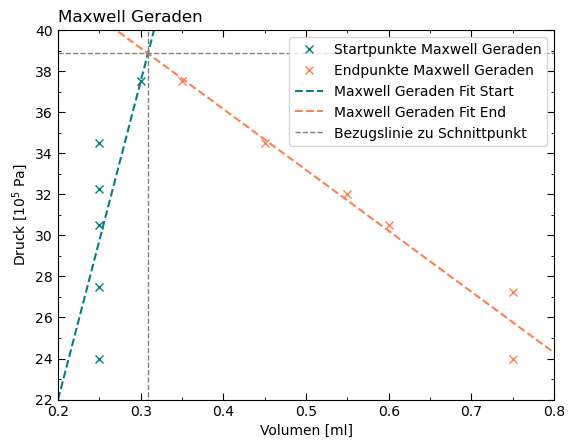

In [50]:
def lin(x,a,b):
    return a*x + b

paramsS, covS = sc.curve_fit(lin, MGS[:,1], MGS[:,0])
errorsS = np.sqrt(np.diag(covS))
paramsE, covE = sc.curve_fit(lin, MGE[:,1], MGE[:,0])
errorsE = np.sqrt(np.diag(covE))


aS, bS = paramsS
aE, bE = paramsE
x_int = (bE - bS) / (aS - aE)
y_int = aS * x_int + bS

print('Fitparameter Startpunkte Maxwell Geraden:', paramsS)
print('Fitparameter Endpunkte Maxwell Geraden:', paramsE)
print("Intersection point: (", x_int, ",", y_int, ")")


plt.plot(MGS[:,1], MGS[:,0], linestyle='none', marker='x', label='Startpunkte Maxwell Geraden', color='teal')
plt.plot(MGE[:,1], MGE[:,0], linestyle='none', marker='x', label='Endpunkte Maxwell Geraden', color='coral')
plt.plot(np.linspace(0.2,0.8,100), lin(np.linspace(0.2,0.8,100), *paramsS), label='Maxwell Geraden Fit Start', linestyle='--', color='teal')
plt.plot(np.linspace(0.2,0.8,100), lin(np.linspace(0.2,0.8,100), *paramsE), label='Maxwell Geraden Fit End', linestyle='--', color='coral')
plt.hlines(y=y_int, color='gray', linestyle='--', xmin=0, xmax=1, linewidth=1, label='Bezugslinie zu Schnittpunkt')
plt.vlines(x=x_int, color='gray', linestyle='--', ymin=20, ymax=45, linewidth=1)
plt.xlabel('Volumen [ml]')
plt.ylabel('Druck [10$^5$ Pa]')
plt.title('Maxwell Geraden', loc='left')
plt.gca().yaxis.set_minor_locator(AutoMinorLocator(2))
plt.gca().xaxis.set_minor_locator(AutoMinorLocator(2))
plt.xticks(np.arange(0, 1, 0.1))
plt.yticks(np.arange(20, 42, 2))
plt.tick_params(axis='both', which='minor', direction='in', right=True, top=True)
plt.tick_params(axis='both', which='major', direction='in', right=True, top=True, length=5)
plt.xlim(0.2, 0.8)
plt.ylim(22, 40)
plt.legend()